In [1]:
import json
import os
import sys
import hashlib
from pathlib import Path
from datetime import datetime

import wandb
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from dotenv import load_dotenv

sys.path.append(os.path.abspath("../.."))

from src.utils.get_trainer import get_trainer
from src.utils.loggers import WandbLogger
from src.utils.telegram import send_message

## Create OOF and Test pred

In [2]:
# ===== User config =====
load_dotenv(dotenv_path="../../.env")

model_name = "xgb"
data_id = "002"

n_trial = 5

n_folds = 5
seed = 42

In [3]:
# === get params, n_folds, seed, and batch_rows ===
study_name = f"{model_name}-{data_id}"
feature_dir = Path(f"../../artifacts/features/{data_id}")

params_id = f"trl{n_trial}"
params_path = f"../../artifacts/optuna/{study_name}/{params_id}.json"

with open(feature_dir / "meta.json", "r") as f:
    meta = json.load(f)

train_paths = meta["train_paths"]
test_paths = meta["test_paths"]
level = meta["level"]

with open(params_path, "r") as f:
    manifest = json.load(f)

params = manifest["params"]
opts = manifest["opts"]

print("Manifest path: ", params_path)
print("Params:\n", params)
print("opts: ", opts)

Manifest path:  ../../artifacts/optuna/xgb-002/trl5.json
Params:
 {'learning_rate': 0.02, 'max_depth': 10, 'min_child_weight': 17.052412368729154, 'colsample_bytree': 0.3260206371941118, 'subsample': 0.8795542149013333, 'reg_alpha': 25.676071644288232, 'reg_lambda': 1.1015056790269626}
opts:  {'earlys_stopping_rounds': 5, 'max_epochs': 20, 'min_epochs': 4}


In [4]:
# === WANDB ===
wandb_project = os.environ.get("COMPETITION_NAME")
wandb.login(key=os.environ.get("WANDB_API_KEY"))

run = wandb.init(
    project=wandb_project,
    group=study_name,
    name=params_id,
    job_type="cv_training",
    tags=[model_name, level],
    config={
        "data_id": data_id,
        "n_folds": n_folds,
        "seed": seed,
        **params,
        **opts
    },
    dir="../../artifacts",
    reinit="finish_previous"
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/hanse/.netrc
wandb: Currently logged in as: kaitookano (kaitookano-waseda-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
# === Training ===
trainer_class = get_trainer(model_name)
trainer = trainer_class(
    data_id,
    train_paths,
    test_paths,
    features=None,
    target="target",
    fold_col=None,
    weight_col=None,
    cat_cols=None,
    params=params,
    n_folds=n_folds,
    seed=seed,
    gpu=True,
    opts=opts
)

result = trainer.fit(
    loggers=[WandbLogger(run=run)]
)

Fold Col: 5fold-s42
================== Fold 1 / 5 ==================
Free CPU Mem: 14.5 GB
Free GPU Mem: 6.89 GB
[0]	train-auc:0.94799	valid-auc:0.94824
[100]	train-auc:0.96207	valid-auc:0.96147
[200]	train-auc:0.96532	valid-auc:0.96436
[300]	train-auc:0.96756	valid-auc:0.96618
[400]	train-auc:0.96921	valid-auc:0.96744
[500]	train-auc:0.97054	valid-auc:0.96838
[600]	train-auc:0.97158	valid-auc:0.96899
[700]	train-auc:0.97242	valid-auc:0.96945
[800]	train-auc:0.97315	valid-auc:0.96980
[900]	train-auc:0.97383	valid-auc:0.97014
[1000]	train-auc:0.97445	valid-auc:0.97043
[1100]	train-auc:0.97496	valid-auc:0.97062
[1200]	train-auc:0.97544	valid-auc:0.97079
[1300]	train-auc:0.97591	valid-auc:0.97094
[1400]	train-auc:0.97633	valid-auc:0.97105
[1500]	train-auc:0.97671	valid-auc:0.97114
[1600]	train-auc:0.97709	valid-auc:0.97124
[1700]	train-auc:0.97747	valid-auc:0.97135
[1800]	train-auc:0.97779	valid-auc:0.97141
[1900]	train-auc:0.97808	valid-auc:0.97145
[2000]	train-auc:0.97840	valid-auc:0.97

iter_f1,▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇██
iter_f2,▁▁▂▂▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇████
iter_f3,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█
iter_f4,▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇████
iter_f5,▁▁▁▂▂▃▃▄▄▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇█████
train/f1/auc,▁▁▂▃▃▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████
train/f2/auc,▁▃▃▄▄▄▄▄▄▅▅▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇██████████
train/f3/auc,▁▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇███
train/f4/auc,▁▁▃▃▄▅▅▅▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██
train/f5/auc,▁▃▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇███████████████
valid/f1/auc,▁▂▂▄▄▆▆▆▆▆▇▇▇▇▇█████████████████████████


In [6]:
# ===== Save Manifest, OOF, and Test pred=====
runs_root = Path("../../runs")
run_id = f"{model_name}-{data_id}-{params_id}-{n_folds}fold-s{seed}"
run_dir = runs_root / run_id
run_dir.mkdir(parents=True, exist_ok=True)

s = json.dumps(params, sort_keys=True, separators=(",", ":"), ensure_ascii=False)
phash = hashlib.sha256(s.encode()).hexdigest()[:10]

manifest = {
    "run_id": run_id,
    "wandb_id": run.id,
    "wandb_url": run.url,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_name": model_name,
    "data_id": data_id,
    "n_folds": n_folds,
    "seed": seed,
    "feature_dir": str(feature_dir.resolve()),
    "phash": phash,
    "param_source": params_path,
    "params": params,
    "run_dir": str(run_dir.resolve()),
    "cv_score": float(result["oof_score"]),
    "submission": {
        "competition": None,
        "ref": None,
        "file": None,
        "public_score": None,
        "private_score": None,
        "submitted_at": None
    }
}

with open(run_dir / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=4)

print("manifest saved", run_dir / "manifest.json")

# oof and test pred
np.save(run_dir / "oof.npy", result["oof"])
np.save(run_dir / "test.npy", result["test_pred"])

print(f"oof and test preds saved successfully in:\n{run_dir}")
send_message(
    f"✅ Finished CV for {run_id}!"
    f"\nScore: {round(result['oof_score'], 5)}"
)

manifest saved ../../runs/xgb-002-trl5-5fold-s42/manifest.json
oof and test preds saved successfully in:
../../runs/xgb-002-trl5-5fold-s42
✅ Message sent.


## Check Feature Importance (Only XGB or LGBM)

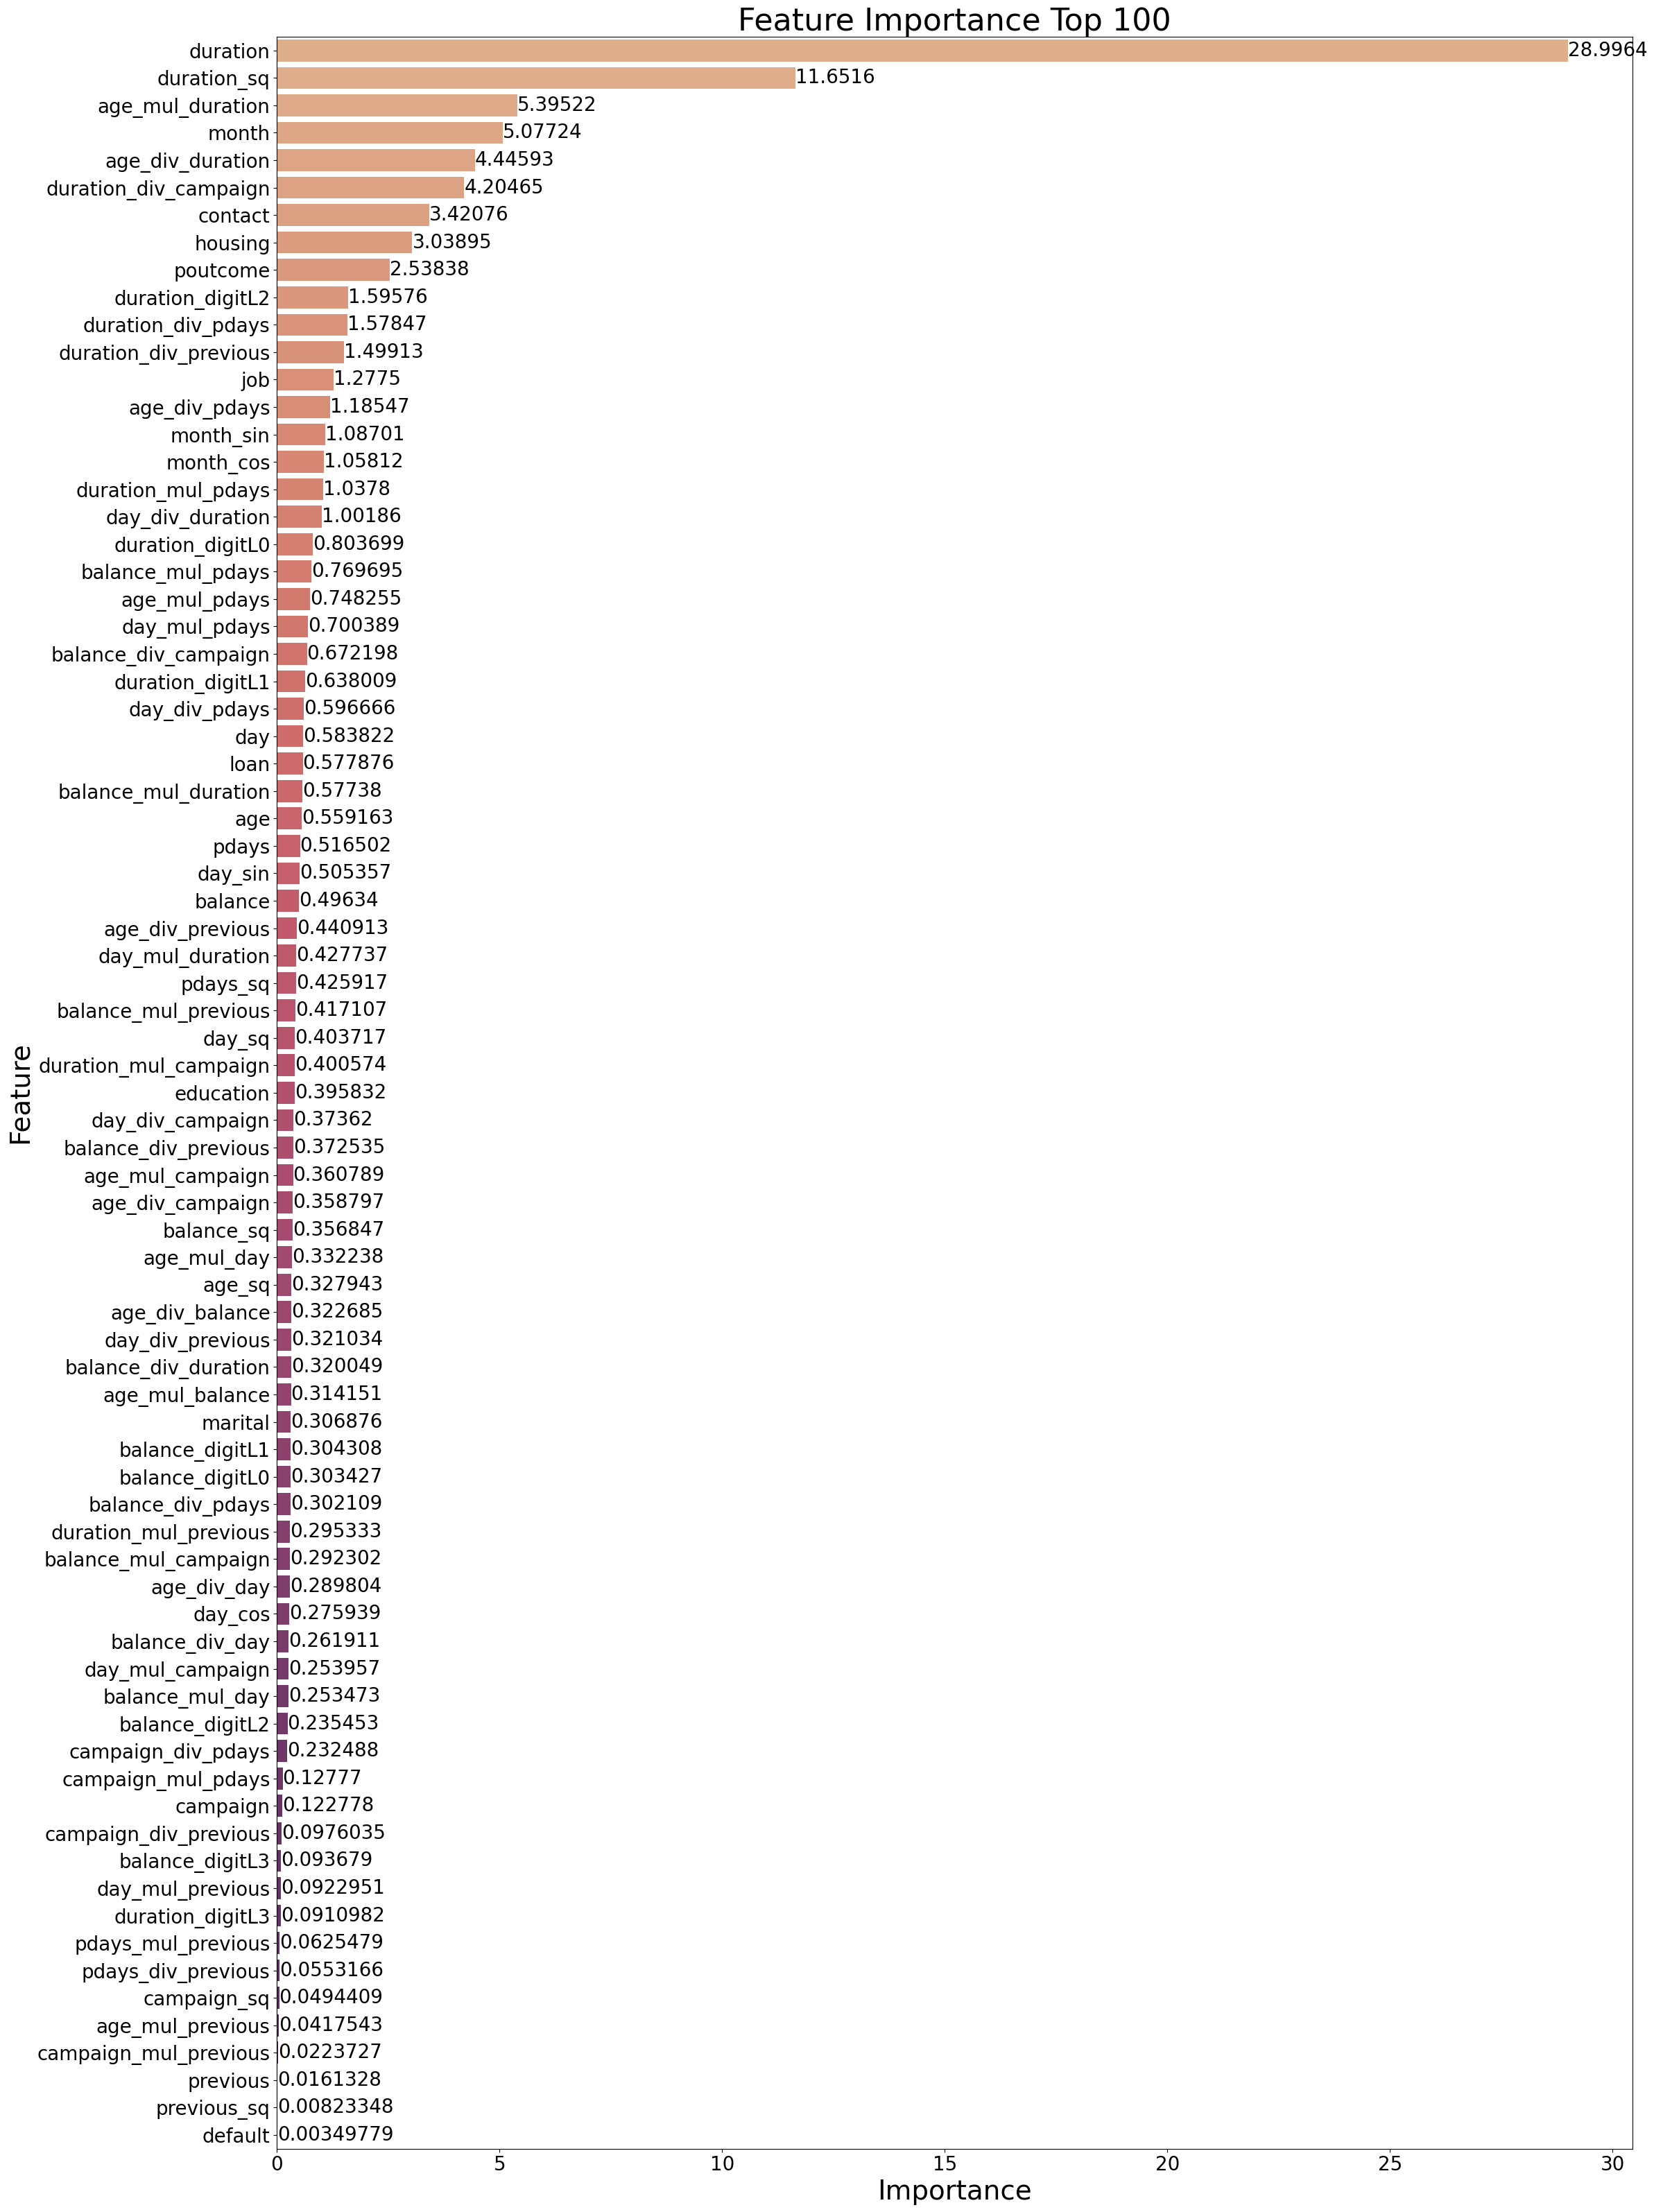

FI graph saved successfully to ../../runs/xgb-002-trl5-5fold-s42


In [7]:
# Plot feature importance and get top columns
df = result["fi_mean"].to_pandas()
df_top100 = df[:100]

fig, ax = plt.subplots(figsize=(24, 32))
sns.barplot(
    data=df_top100,
    y="Feature",
    x="Importance",
    orient="h",
    palette="flare",
    hue="Feature",
    ax=ax
)
for container in ax.containers:
    labels = ax.bar_label(container)
    for label in labels:
        label.set_fontsize(20)
plt.title("Feature Importance Top 100", fontsize=32)
plt.xlabel("Importance", fontsize=28)
plt.ylabel("Feature", fontsize=28)
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)
plt.tight_layout()

fig.savefig(run_dir / "feature_importance.png", dpi=200, bbox_inches="tight")
fig.savefig(run_dir / "feature_importance.svg", bbox_inches="tight")

plt.show()

print(f"FI graph saved successfully to {run_dir}")

In [8]:
# Save low important cols
thresholds = [0.90, 0.95, 0.99]       # しきい値リスト

total = df["Importance"].sum()
print("All cols ", len(df))

out = {}
for th in thresholds:
    limit = th * total                # このしきい値に対応する累積比率

    # 累積と K を計算（「閾値を超える要素も1つ含める」ロジック）
    cum = df["Importance"].cumsum()
    k = int((cum <= limit).sum())
    if k < len(df):
        k += 1

    drop_cols = df["Feature"].iloc[k:].tolist()
    print(f"\nThreshold {th:.2f} → Drop {len(drop_cols)} cols")
    out[str(k)] = drop_cols

path = run_dir / "drop_cols.json"
with open(path, "w", encoding="utf-8") as f:
    json.dump(out, f, ensure_ascii=False, indent=4)
print(f"saved: {path}")

All cols  77

Threshold 0.90 → Drop 42 cols

Threshold 0.95 → Drop 28 cols

Threshold 0.99 → Drop 14 cols
saved: ../../runs/xgb-002-trl5-5fold-s42/drop_cols.json
